# Hybrid-electric turboprop

A parallel hybrid: a battery-fed electric motor shares the propeller shaft with the
gas turbine. The cruise battery share is set by the supplied-power ratio `phi`.

In [1]:
import sys, os
# reuse the baseline configs in examples/common.py (works whether the notebook is run
# from trunk/ or from trunk/notebooks/).
for _p in (os.path.join(os.getcwd(), 'examples'), os.path.join(os.getcwd(), '..', 'examples')):
    if os.path.isdir(_p):
        sys.path.insert(0, _p)
import matplotlib.pyplot as plt
import PhlyGreen as pg
from PhlyGreen import postprocess as pp
from common import hybrid_config

## Build the design specification

Raise the cruise `phi` to draw more power from the battery (heavier battery, less fuel).

In [2]:
config = hybrid_config()
for seg in config.mission_stages.segments:
    if seg.name == 'Cruise':
        seg.phi_end = 0.5     # battery supplies up to 50% of cruise power
print('hybrid type:', config.hybrid_type)

hybrid type: Parallel


## Size the aircraft and read the results

In [3]:
aircraft = pg.build_aircraft()
aircraft.configure(config)
r = aircraft.results()
print(f'take-off weight : {r.WTO:8.1f} kg')
print(f'mission fuel    : {r.Wf:8.1f} kg')
print(f'battery mass    : {r.WBat:8.1f} kg')
print(f'battery pack    : {r.pack_energy/3.6e6:6.1f} kWh, {r.pack_power_max/1000:6.1f} kW')

max=58 and min=56
Optimal n 57


max=341 and min=340
Optimal n 341


max=119 and min=118
Optimal n 119


max=125 and min=124
Optimal n 125


max=125 and min=124
Optimal n 125


max=125 and min=124
Optimal n 125


max=125 and min=124
Optimal n 125
take-off weight :  21910.5 kg
mission fuel    :   1572.8 kg
battery mass    :   1686.2 kg
battery pack    :    0.7 kWh, 13563.4 kW


## Plot every outcome (note the battery energy and state-of-charge traces)

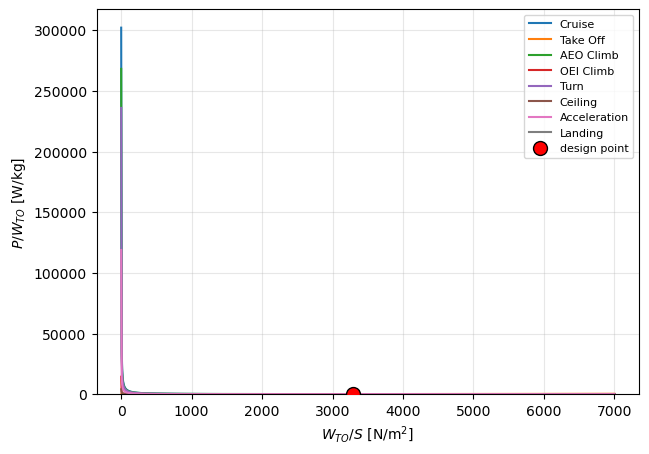

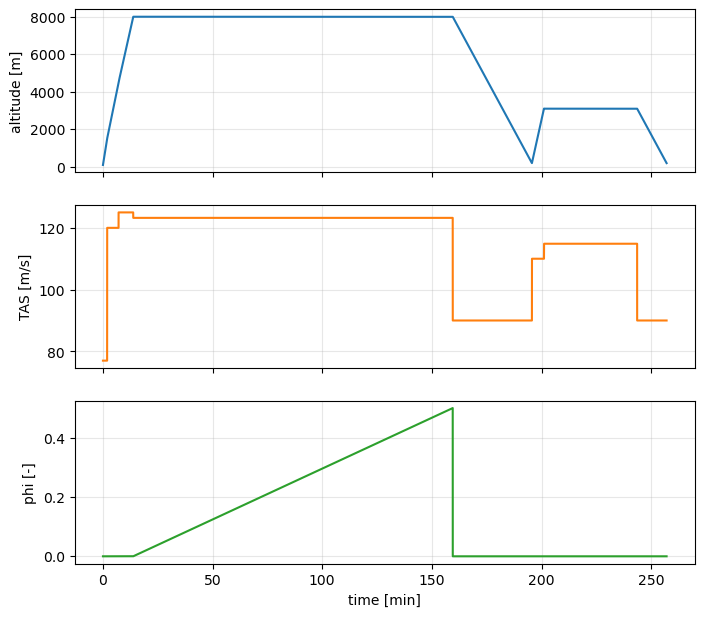

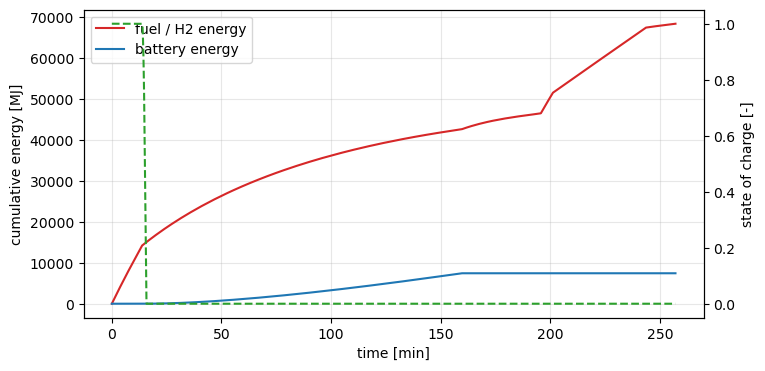

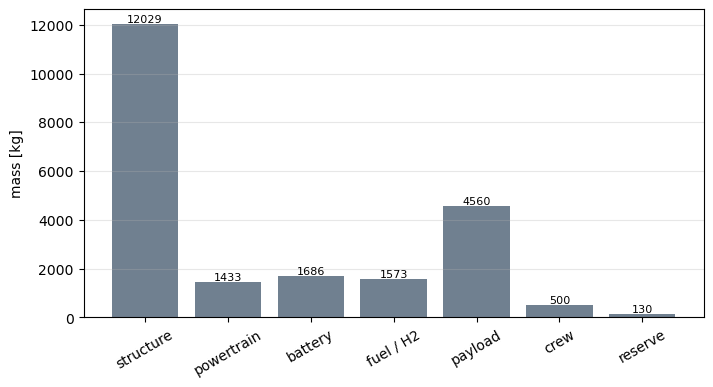

In [4]:
# Every outcome, including the time-resolved ones, via the generic post-processing helpers.
pp.plot_constraint_diagram(aircraft); plt.show()
pp.plot_mission_profile(aircraft);    plt.show()
pp.plot_energy_timeseries(aircraft);  plt.show()
pp.plot_mass_breakdown(aircraft);     plt.show()
